In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from scipy.optimize import curve_fit
plt.style.use("style.mplstyle")

In [5]:
dataset = baseClasses.Data()

In [6]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30, 0)) & (dataset.data.index < datetime.datetime(2024, 5, 9)))
)
dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [7]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

In [8]:
class Bulk:
    def __init__(self, dataset, system_name="TGRAD"):
        self.dataset = dataset
        self.system_name = system_name
        self.system = systemClasses.System(self.dataset, self.system_name)
        self._calibrate()

    def _calibrate(self, calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500"):
        self.system.calibrate(calibName=calibName)
        return self

    def define_bottom(self, h0=0, hf=1000):
        self.bottom_sensors = {}
        for id, sensor in self.system.sensors.items():
            if (self.system_name == "APA") and ("F" in sensor.name) and (("APA3" not in sensor.name) or ("APA4" not in sensor.name)):
                continue
            if sensor.Y > h0 and sensor.Y < hf:
                self.bottom_sensors[sensor.id] = sensor
        return self

    def define_middle(self, h0=1000, hf=5000):
        self.middle_sensors = {}
        for id, sensor in self.system.sensors.items():
            if (self.system_name == "APA") and ("F" in sensor.name):
                continue
            if sensor.Y >= h0 and sensor.Y < hf:
                self.middle_sensors[sensor.id] = sensor
        return self

    def define_top(self, h0=5000, hf=8000):
        self.top_sensors = {}
        for id, sensor in self.system.sensors.items():
            if (self.system_name == "APA") and ("F" in sensor.name):
                continue
            if sensor.Y >= h0 and sensor.Y < hf:
                self.top_sensors[sensor.id] = sensor
        return self

    def define(self):
        if len(self.system.sensors) == 0:
            raise ValueError("No sensors defined in the system.")
        if not hasattr(self, 'bottom_sensors'):
            self.define_bottom()
        if not hasattr(self, 'middle_sensors'):
            self.define_middle()
        if not hasattr(self, 'top_sensors'):
            self.define_top()
        # Merge sensor data into self.bottom, adding each as a new column
        self.bottom = pd.DataFrame()
        for id, sensor in self.bottom_sensors.items():
            sensor_df = sensor.data.squeeze()
            self.bottom[id] = sensor_df
        # Keep only the mean and std columns in self.bottom
        self.bottom['mean'] = self.bottom.mean(axis=1)
        self.bottom['std'] = self.bottom.std(axis=1)
        self.bottom = self.bottom[['mean', 'std']]

        self.middle = pd.DataFrame()
        for id, sensor in self.middle_sensors.items():
            sensor_df = sensor.data.squeeze()
            self.middle[id] = sensor_df
        self.middle['mean'] = self.middle.mean(axis=1)
        self.middle['std'] = self.middle.std(axis=1)
        self.middle = self.middle[['mean', 'std']]

        self.top = pd.DataFrame()
        for id, sensor in self.top_sensors.items():
            sensor_df = sensor.data.squeeze()
            self.top[id] = sensor_df
        self.top['mean'] = self.top.mean(axis=1)
        self.top['std'] = self.top.std(axis=1)
        self.top = self.top[['mean', 'std']]
        return self


In [11]:
bulk = Bulk(dataset, system_name="TGRAD")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  9.34sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 116.00sensor/s]


In [12]:
bulk.define_bottom(h0=0, hf=1150)
bulk.define_middle(h0=1150, hf=5000)
bulk.define_top(h0=5000, hf=8000)
bulk.define()

In [13]:
print(bulk.top_sensors)

{39666: <src.sensorClasses.Sensor object at 0x123432f70>, 39665: <src.sensorClasses.Sensor object at 0x123433040>, 39664: <src.sensorClasses.Sensor object at 0x123432dd0>, 39667: <src.sensorClasses.Sensor object at 0x1234331e0>, 39661: <src.sensorClasses.Sensor object at 0x123432ea0>, 39660: <src.sensorClasses.Sensor object at 0x123f518b0>, 39655: <src.sensorClasses.Sensor object at 0x11259c530>, 39654: <src.sensorClasses.Sensor object at 0x11259c120>, 39653: <src.sensorClasses.Sensor object at 0x11259c1f0>, 39652: <src.sensorClasses.Sensor object at 0x11259c460>, 99999: <src.sensorClasses.Sensor object at 0x11259c050>, 39651: <src.sensorClasses.Sensor object at 0x11252bad0>, 39650: <src.sensorClasses.Sensor object at 0x11252b790>, 40526: <src.sensorClasses.Sensor object at 0x11252bc70>, 40525: <src.sensorClasses.Sensor object at 0x11252bba0>, 40524: <src.sensorClasses.Sensor object at 0x11252bd40>, 39659: <src.sensorClasses.Sensor object at 0x11252bee0>, 39658: <src.sensorClasses.Sens

In [14]:
inlet = sensorClasses.Sensor(dataset=dataset, id=49321).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")

(87.25, 92.8)

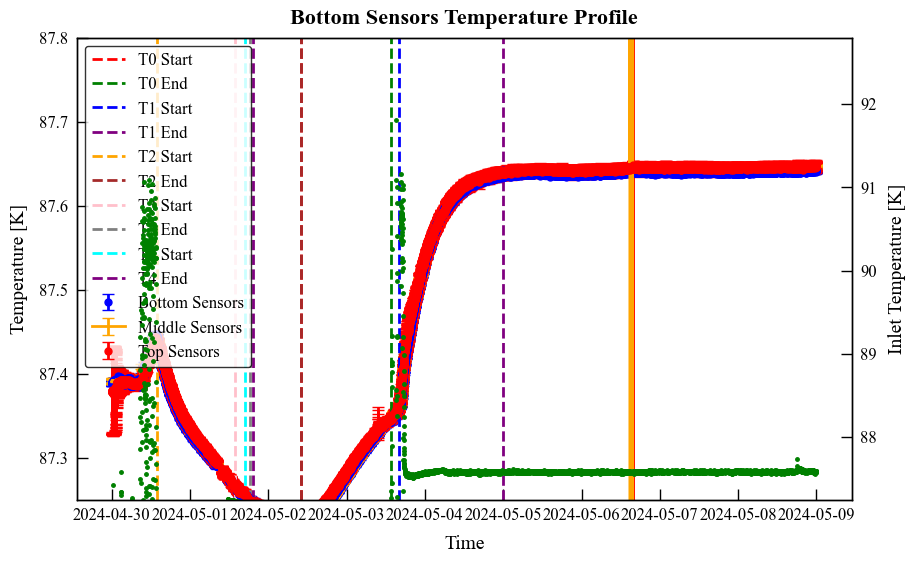

In [15]:
t0_ini, t0_end = datetime.datetime(2024, 5, 2, 10, 8), datetime.datetime(2024, 5, 3, 13, 30)
t1_ini, t1_end = datetime.datetime(2024, 5, 3, 16, 0), datetime.datetime(2024, 5, 5, 0, 0)
t2_ini, t2_end = datetime.datetime(2024, 4, 30, 13, 58), datetime.datetime(2024, 5, 2, 10, 8)
t3_ini, t3_end = datetime.datetime(2024, 5, 1, 13, 45), datetime.datetime(2024, 5, 1, 18, 15)
t4_ini, t4_end = datetime.datetime(2024, 5, 1, 16, 45), datetime.datetime(2024, 5, 1, 19, 20)

fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.errorbar(bulk.bottom.index, bulk.bottom['mean'], yerr=bulk.bottom['std'], fmt='o', label="Bottom Sensors", color="blue")
axes.errorbar(bulk.middle.index, bulk.middle['mean'], yerr=bulk.middle['std'], fmt='-', label="Middle Sensors", color="orange")
axes.errorbar(bulk.top.index, bulk.top['mean'], yerr=bulk.top['std'], fmt='o', label="Top Sensors", color="red")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("Bottom Sensors Temperature Profile")
axes.set_ylim(87.25, 87.8)
axes.axvline(t0_ini, color='red', linestyle='--', label='T0 Start')
axes.axvline(t0_end, color='green', linestyle='--', label='T0 End')
axes.axvline(t1_ini, color='blue', linestyle='--', label='T1 Start')
axes.axvline(t1_end, color='purple', linestyle='--', label='T1 End')
axes.axvline(t2_ini, color='orange', linestyle='--', label='T2 Start')
axes.axvline(t2_end, color='brown', linestyle='--', label='T2 End')
axes.axvline(t3_ini, color='pink', linestyle='--', label='T3 Start')
axes.axvline(t3_end, color='gray', linestyle='--', label='T3 End')
axes.axvline(t4_ini, color='cyan', linestyle='--', label='T4 Start')
axes.axvline(t4_end, color='purple', linestyle='--', label='T4 End')
axes.legend()
axes2 = axes.twinx()
axes2.plot(inlet.data.index.values, inlet.data.values, ".", label="Inlet Temperature", color="green")
axes2.set_ylabel("Inlet Temperature [K]")
axes2.set_ylim(87.25, 92.8)

Delta T CE: -0.015417002237839483
Delta t CE: 0 days 04:28:00
Delta T CE / Delta t CE: -9.5876879588554e-07
Average Power: -69.80 W
Heat produced (Q): -1.12e+06 J over 4.5 h


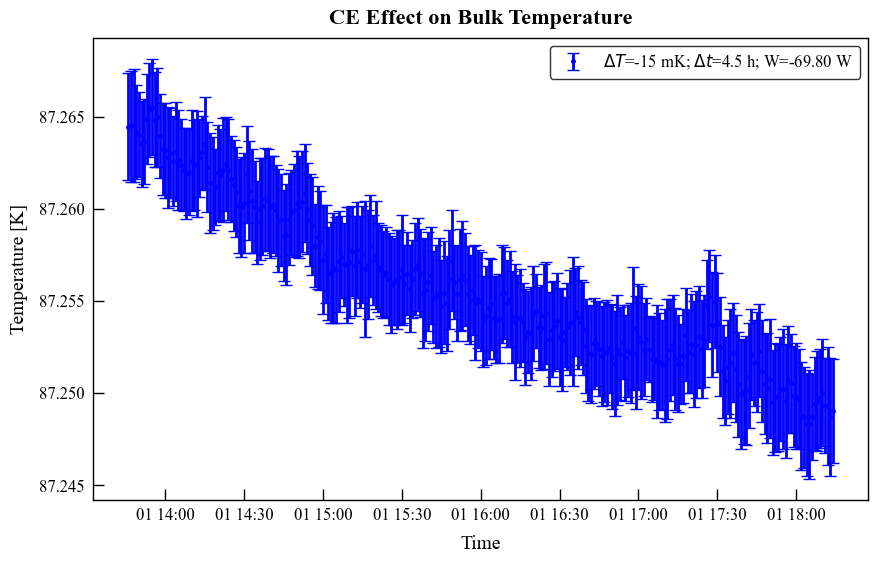

In [16]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
ce_effect = bulk.bottom.loc[(bulk.bottom.index>t3_ini)&(bulk.bottom.index<t3_end)]
deltaT_ce = ce_effect['mean'].iloc[-1] - ce_effect['mean'].iloc[0]
deltat_ce = ce_effect.index[-1] - ce_effect.index[0]
print("Delta T CE:", deltaT_ce)
print("Delta t CE:", deltat_ce)
print("Delta T CE / Delta t CE:", deltaT_ce / deltat_ce.total_seconds())

# Constants
mass_lar = 1.4e5  # kg, example mass of liquid argon (adjust as needed)
c_lar = 0.52e3    # J/(kg*K), specific heat capacity of liquid argon

# Time in seconds (27.3 hours)
dt_seconds = deltat_ce.total_seconds()  # Convert timedelta to seconds

# Use deltaT (already defined) as the temperature rise in K
Q = mass_lar * c_lar * deltaT_ce  # Heat produced in Joules
# Calculate average power in Watts (Joules per second)
power_W = Q / dt_seconds
print(f"Average Power: {power_W:.2f} W")
print(f"Heat produced (Q): {Q:.2e} J over {dt_seconds/3600:.1f} h")
axes.errorbar(ce_effect.index, ce_effect['mean'], yerr=ce_effect['std'], fmt='.', label=fr"$\Delta T$={1e3*deltaT_ce:.0f} mK; $\Delta t$={deltat_ce.total_seconds()/3600:.1f} h; W={power_W:.2f} W", color="blue")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("CE Effect on Bulk Temperature")
# axes.set_ylim(87.25, 87.8)
axes.legend()

Delta T CE: -0.012805892113860295
Delta t CE: 0 days 02:33:00
Delta T CE / Delta t CE: -1.3949773544510126e-06
Average Power: -101.55 W
Heat produced (Q): -9.32e+05 J over 2.5 h


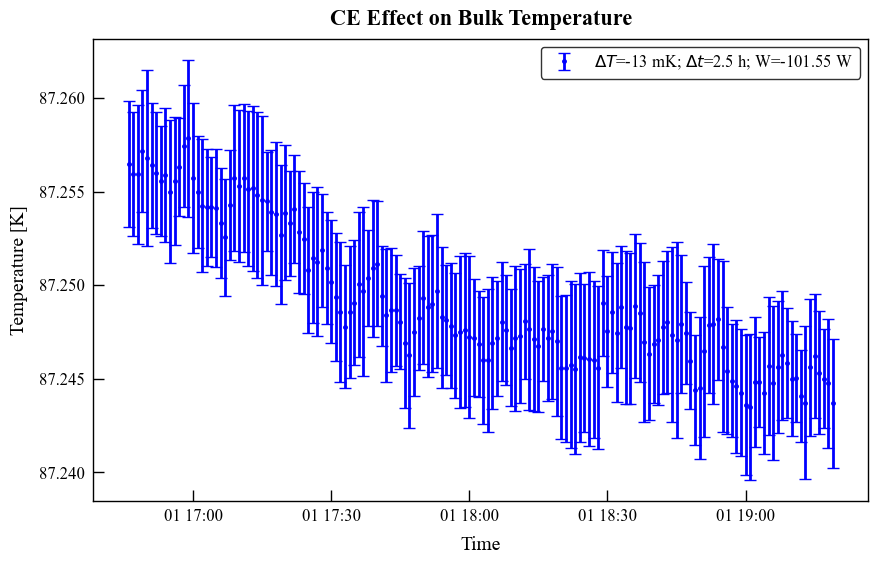

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
ce_effect = bulk.top.loc[(bulk.top.index>t4_ini)&(bulk.top.index<t4_end)]
deltaT_ce = ce_effect['mean'].iloc[-1] - ce_effect['mean'].iloc[0]
deltat_ce = ce_effect.index[-1] - ce_effect.index[0]
print("Delta T CE:", deltaT_ce)
print("Delta t CE:", deltat_ce)
print("Delta T CE / Delta t CE:", deltaT_ce / deltat_ce.total_seconds())

# Constants
mass_lar = 1.4e5  # kg, example mass of liquid argon (adjust as needed)
c_lar = 0.52e3    # J/(kg*K), specific heat capacity of liquid argon

# Time in seconds (27.3 hours)
dt_seconds = deltat_ce.total_seconds()  # Convert timedelta to seconds

# Use deltaT (already defined) as the temperature rise in K
Q = mass_lar * c_lar * deltaT_ce  # Heat produced in Joules
# Calculate average power in Watts (Joules per second)
power_W = Q / dt_seconds
print(f"Average Power: {power_W:.2f} W")
print(f"Heat produced (Q): {Q:.2e} J over {dt_seconds/3600:.1f} h")
axes.errorbar(ce_effect.index, ce_effect['mean'], yerr=ce_effect['std'], fmt='.', label=fr"$\Delta T$={1e3*deltaT_ce:.0f} mK; $\Delta t$={deltat_ce.total_seconds()/3600:.1f} h; W={power_W:.2f} W", color="blue")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("CE Effect on Bulk Temperature")
# axes.set_ylim(87.25, 87.8)
axes.legend()

Delta T CE: 0.12593864218455053
Delta t CE: 1 days 03:20:00
Delta T CE / Delta t CE: 1.2798642498429933e-06
Average Power: 93.17 W
Heat produced (Q): 9.17e+06 J over 27.3 h


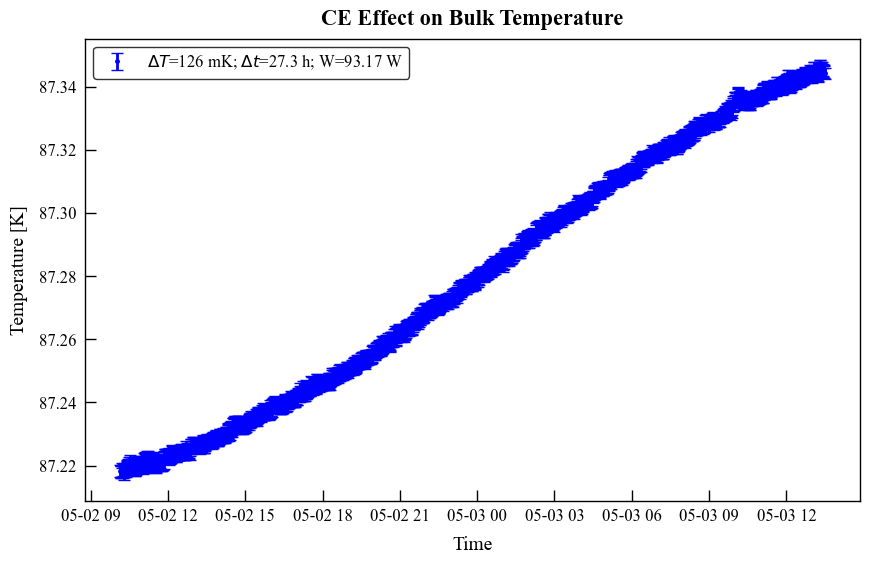

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
ce_effect = bulk.middle.loc[(bulk.middle.index>t0_ini)&(bulk.middle.index<t0_end)]
deltaT_ce = ce_effect['mean'].iloc[-1] - ce_effect['mean'].iloc[0]
deltat_ce = ce_effect.index[-1] - ce_effect.index[0]
print("Delta T CE:", deltaT_ce)
print("Delta t CE:", deltat_ce)
print("Delta T CE / Delta t CE:", deltaT_ce / deltat_ce.total_seconds())

# Constants
mass_lar = 1.4e5  # kg, example mass of liquid argon (adjust as needed)
c_lar = 0.52e3    # J/(kg*K), specific heat capacity of liquid argon

# Time in seconds (27.3 hours)
dt_seconds = deltat_ce.total_seconds()  # Convert timedelta to seconds

# Use deltaT (already defined) as the temperature rise in K
Q = mass_lar * c_lar * deltaT_ce  # Heat produced in Joules
# Calculate average power in Watts (Joules per second)
power_W = Q / dt_seconds
print(f"Average Power: {power_W:.2f} W")
print(f"Heat produced (Q): {Q:.2e} J over {dt_seconds/3600:.1f} h")
axes.errorbar(ce_effect.index, ce_effect['mean'], yerr=ce_effect['std'], fmt='.', label=fr"$\Delta T$={1e3*deltaT_ce:.0f} mK; $\Delta t$={deltat_ce.total_seconds()/3600:.1f} h; W={power_W:.2f} W", color="blue")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("CE Effect on Bulk Temperature")
# axes.set_ylim(87.25, 87.8)
axes.legend()

Delta T CE: -0.21957989140013012
Delta t CE: 1 days 20:08:00
Delta T CE / Delta t CE: -1.3820486618840014e-06
Average Power: -100.61 W
Heat produced (Q): -1.60e+07 J over 44.1 h


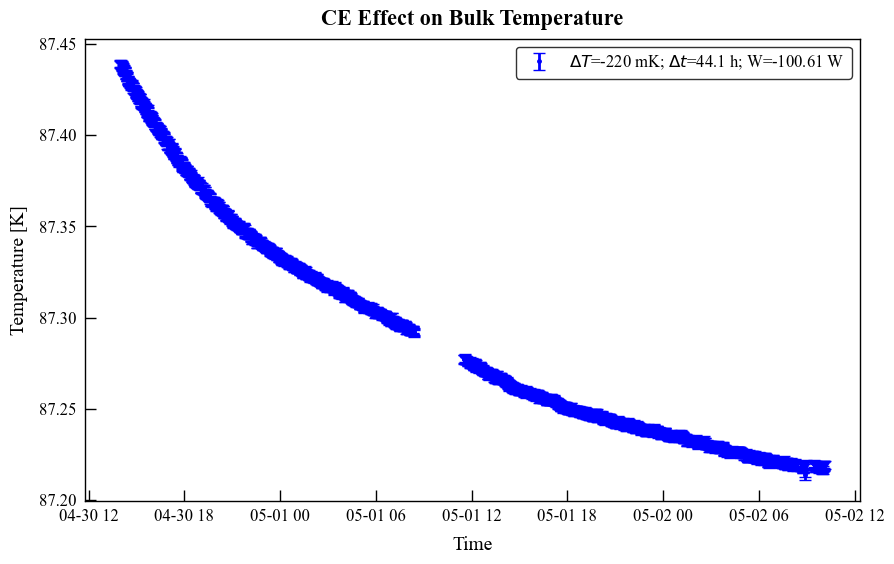

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
ce_effect = bulk.middle.loc[(bulk.middle.index>t2_ini)&(bulk.middle.index<t2_end)]
deltaT_ce = ce_effect['mean'].iloc[-1] - ce_effect['mean'].iloc[0]
deltat_ce = ce_effect.index[-1] - ce_effect.index[0]
print("Delta T CE:", deltaT_ce)
print("Delta t CE:", deltat_ce)
print("Delta T CE / Delta t CE:", deltaT_ce / deltat_ce.total_seconds())

# Constants
mass_lar = 1.4e5  # kg, example mass of liquid argon (adjust as needed)
c_lar = 0.52e3    # J/(kg*K), specific heat capacity of liquid argon

# Time in seconds (27.3 hours)
dt_seconds = deltat_ce.total_seconds()  # Convert timedelta to seconds

# Use deltaT (already defined) as the temperature rise in K
Q = mass_lar * c_lar * deltaT_ce  # Heat produced in Joules
# Calculate average power in Watts (Joules per second)
power_W = Q / dt_seconds
print(f"Average Power: {power_W:.2f} W")
print(f"Heat produced (Q): {Q:.2e} J over {dt_seconds/3600:.1f} h")
axes.errorbar(ce_effect.index, ce_effect['mean'], yerr=ce_effect['std'], fmt='.', label=fr"$\Delta T$={1e3*deltaT_ce:.0f} mK; $\Delta t$={deltat_ce.total_seconds()/3600:.1f} h; W={power_W:.2f} W", color="blue")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("CE Effect on Bulk Temperature")
# axes.set_ylim(87.25, 87.8)
axes.legend()

Delta T LAr: 0.2830683478976539
Delta t LAr: 1 days 07:58:00
Delta T LAr / Delta t LAr: 2.4597527624057518e-06
Average Power: 179.07 W
Heat produced (Q): 2.06e+07 J over 32.0 h


(87.25, 89.0)

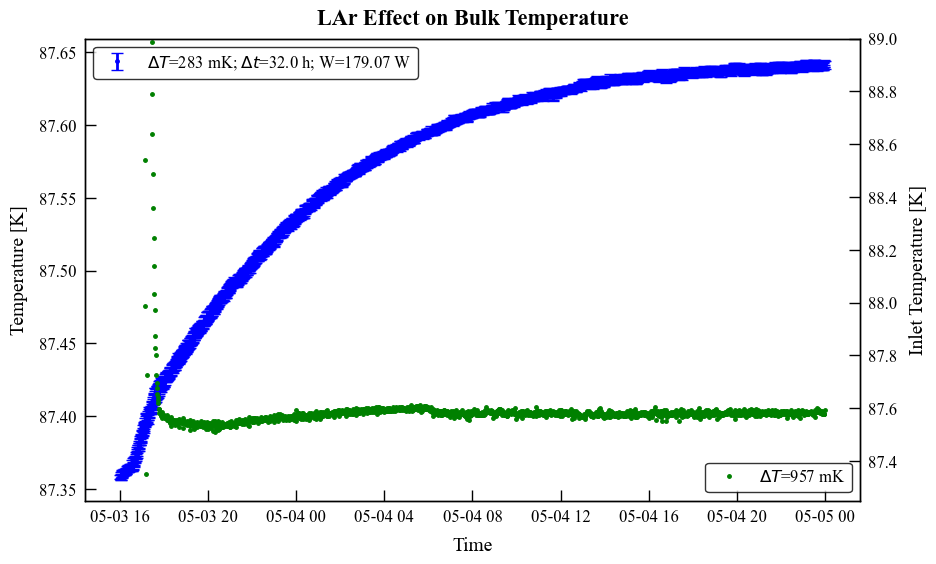

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
lar_effect = bulk.middle.loc[(bulk.middle.index>t1_ini)&(bulk.middle.index<t1_end)]
inlet_effect = inlet.data.loc[(inlet.data.index>t1_ini)&(inlet.data.index<t1_end)]
deltaT_lar = lar_effect['mean'].iloc[-1] - lar_effect['mean'].iloc[0]
deltat_lar = lar_effect.index[-1] - lar_effect.index[0]
deltaT_inlet = inlet_effect.iloc[-1] - inlet_effect.iloc[0]
deltat_inlet = inlet_effect.index[-1] - inlet_effect.index[0]
print("Delta T LAr:", deltaT_lar)
print("Delta t LAr:", deltat_lar)
print("Delta T LAr / Delta t LAr:", deltaT_lar / deltat_lar.total_seconds())

# Constants
mass_lar = 1.4e5  # kg, example mass of liquid argon (adjust as needed)
c_lar = 0.52e3    # J/(kg*K), specific heat capacity of liquid argon

# Time in seconds (27.3 hours)
dt_seconds = deltat_lar.total_seconds()  # Convert timedelta to seconds

# Use deltaT (already defined) as the temperature rise in K
Q = mass_lar * c_lar * deltaT_lar  # Heat produced in Joules
# Calculate average power in Watts (Joules per second)
power_W = Q / dt_seconds
print(f"Average Power: {power_W:.2f} W")
print(f"Heat produced (Q): {Q:.2e} J over {dt_seconds/3600:.1f} h")
axes.errorbar(lar_effect.index, lar_effect['mean'], yerr=lar_effect['std'], fmt='.', label=fr"$\Delta T$={1e3*deltaT_lar:.0f} mK; $\Delta t$={deltat_lar.total_seconds()/3600:.1f} h; W={power_W:.2f} W", color="blue")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("LAr Effect on Bulk Temperature")
# axes.set_ylim(87.25, 87.8)
axes.legend()
axes2 = axes.twinx()
axes2.plot(inlet_effect.index, inlet_effect.values, ".", label=fr"$\Delta T$={1e3*deltaT_inlet:.0f} mK", color="green")
axes2.set_ylabel("Inlet Temperature [K]")
axes2.legend(loc="lower right")
axes2.set_ylim(87.25, 89)

In [23]:
dataset = baseClasses.Data()

In [24]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 11, 29, 0)) & (dataset.data.index < datetime.datetime(2024, 12, 5)))
)
dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [25]:
bulk = Bulk(dataset, system_name="TGRAD")
bulk.define()

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 11.00sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 120.93sensor/s]


In [19]:
inlet = sensorClasses.Sensor(dataset=dataset, id=49321).muxEqualization().tempCalibration(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")

(87.25, 89.0)

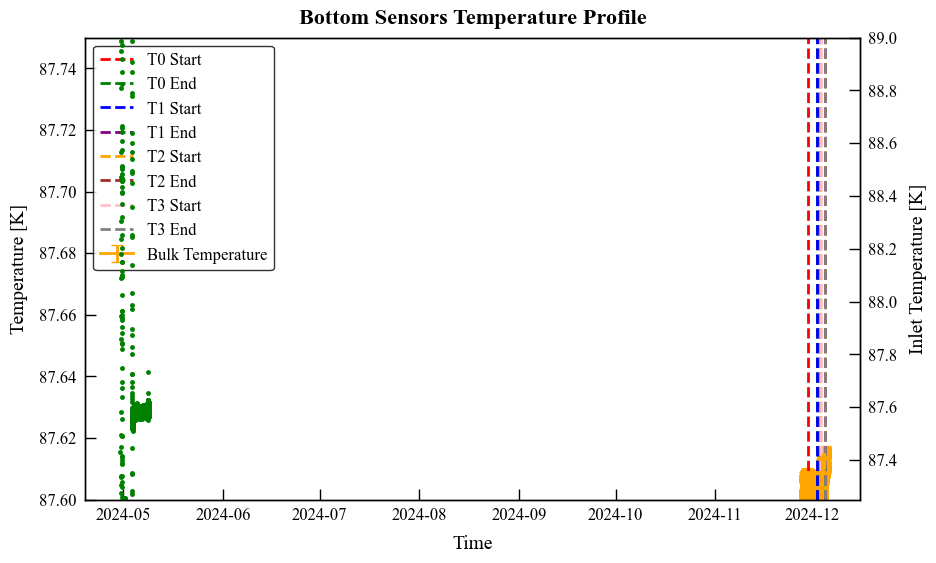

In [26]:
t0_ini, t0_end = datetime.datetime(2024, 11, 29, 23, 0), datetime.datetime(2024, 12, 2, 12, 0)
t1_ini, t1_end = datetime.datetime(2024, 12, 2, 12, 30), datetime.datetime(2024, 12, 3, 11, 30)
t2_ini, t2_end = datetime.datetime(2024, 12, 3, 14, 30), datetime.datetime(2024, 12, 5, 0, 0)
t3_ini, t3_end = datetime.datetime(2024, 12, 3, 17, 32), datetime.datetime(2024, 12, 5, 0, 0)

fig, axes = plt.subplots(1, 1, figsize=(10, 6))
# axes.errorbar(bulk.bottom.index, bulk.bottom['mean'], yerr=bulk.bottom['std'], fmt='o', label="Bottom Sensors", color="blue")
axes.errorbar(bulk.middle.index, bulk.middle['mean'], yerr=bulk.middle['std'], fmt='-', label="Bulk Temperature", color="orange")
# axes.errorbar(bulk.top.index, bulk.top['mean'], yerr=bulk.top['std'], fmt='o', label="Top Sensors", color="red")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("Bottom Sensors Temperature Profile")
axes.set_ylim(87.6, 87.75)
axes.axvline(t0_ini, color='red', linestyle='--', label='T0 Start')
axes.axvline(t0_end, color='green', linestyle='--', label='T0 End')
axes.axvline(t1_ini, color='blue', linestyle='--', label='T1 Start')
axes.axvline(t1_end, color='purple', linestyle='--', label='T1 End')
axes.axvline(t2_ini, color='orange', linestyle='--', label='T2 Start')
axes.axvline(t2_end, color='brown', linestyle='--', label='T2 End')
axes.axvline(t3_ini, color='pink', linestyle='--', label='T3 Start')
axes.axvline(t3_end, color='gray', linestyle='--', label='T3 End')
axes.legend()
axes2 = axes.twinx()
axes2.plot(inlet.data.index.values, inlet.data.values, ".", label="Inlet Temperature", color="green")
axes2.set_ylabel("Inlet Temperature [K]")
axes2.set_ylim(87.25, 89)

Delta T CE: -0.010819210694222647
Delta t CE: 2 days 12:58:00
Delta T CE / Delta t CE: -4.9294745280766574e-08
Average Power: -3.59 W
Heat produced (Q): -7.88e+05 J over 61.0 h


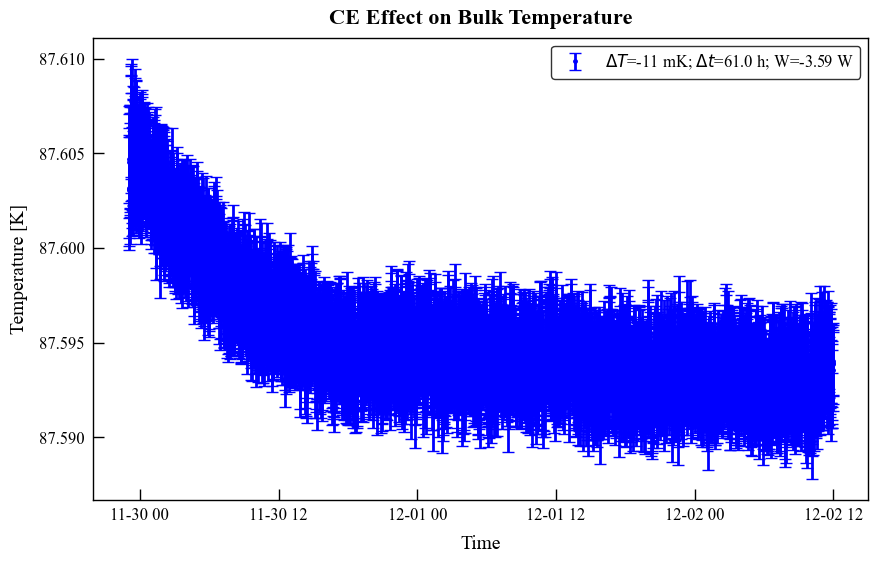

In [27]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
ce_effect = bulk.middle.loc[(bulk.middle.index>t0_ini)&(bulk.middle.index<t0_end)]
deltaT_ce = ce_effect['mean'].iloc[-1] - ce_effect['mean'].iloc[0]
deltat_ce = ce_effect.index[-1] - ce_effect.index[0]
print("Delta T CE:", deltaT_ce)
print("Delta t CE:", deltat_ce)
print("Delta T CE / Delta t CE:", deltaT_ce / deltat_ce.total_seconds())

# Constants
mass_lar = 1.4e5  # kg, example mass of liquid argon (adjust as needed)
c_lar = 0.52e3    # J/(kg*K), specific heat capacity of liquid argon

# Time in seconds (27.3 hours)
dt_seconds = deltat_ce.total_seconds()  # Convert timedelta to seconds

# Use deltaT (already defined) as the temperature rise in K
Q = mass_lar * c_lar * deltaT_ce  # Heat produced in Joules
# Calculate average power in Watts (Joules per second)
power_W = Q / dt_seconds
print(f"Average Power: {power_W:.2f} W")
print(f"Heat produced (Q): {Q:.2e} J over {dt_seconds/3600:.1f} h")
axes.errorbar(ce_effect.index, ce_effect['mean'], yerr=ce_effect['std'], fmt='.', label=fr"$\Delta T$={1e3*deltaT_ce:.0f} mK; $\Delta t$={deltat_ce.total_seconds()/3600:.1f} h; W={power_W:.2f} W", color="blue")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("CE Effect on Bulk Temperature")
# axes.set_ylim(87.25, 87.8)
axes.legend()

Delta T CE: 0.03460959629698834
Delta t CE: 1 days 06:26:00
Delta T CE / Delta t CE: 3.1589627872388046e-07
Average Power: 23.00 W
Heat produced (Q): 2.52e+06 J over 30.4 h


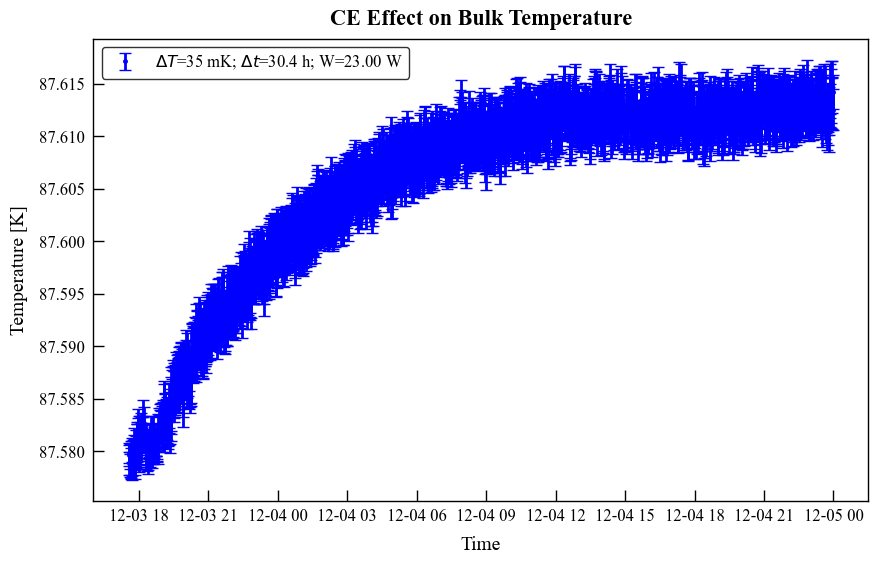

In [22]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
ce_effect = bulk.middle.loc[(bulk.middle.index>t3_ini)&(bulk.middle.index<t3_end)]
deltaT_ce = ce_effect['mean'].iloc[-1] - ce_effect['mean'].iloc[0]
deltat_ce = ce_effect.index[-1] - ce_effect.index[0]
print("Delta T CE:", deltaT_ce)
print("Delta t CE:", deltat_ce)
print("Delta T CE / Delta t CE:", deltaT_ce / deltat_ce.total_seconds())

# Constants
mass_lar = 1.4e5  # kg, example mass of liquid argon (adjust as needed)
c_lar = 0.52e3    # J/(kg*K), specific heat capacity of liquid argon

# Time in seconds (27.3 hours)
dt_seconds = deltat_ce.total_seconds()  # Convert timedelta to seconds

# Use deltaT (already defined) as the temperature rise in K
Q = mass_lar * c_lar * deltaT_ce  # Heat produced in Joules
# Calculate average power in Watts (Joules per second)
power_W = Q / dt_seconds
print(f"Average Power: {power_W:.2f} W")
print(f"Heat produced (Q): {Q:.2e} J over {dt_seconds/3600:.1f} h")
axes.errorbar(ce_effect.index, ce_effect['mean'], yerr=ce_effect['std'], fmt='.', label=fr"$\Delta T$={1e3*deltaT_ce:.0f} mK; $\Delta t$={deltat_ce.total_seconds()/3600:.1f} h; W={power_W:.2f} W", color="blue")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("CE Effect on Bulk Temperature")
# axes.set_ylim(87.25, 87.8)
axes.legend()

Delta T LAr: -0.03609852504334299
Delta t LAr: 0 days 22:58:00
Delta T LAr / Delta t LAr: -4.366052859620584e-07
Average Power: -31.78 W
Heat produced (Q): -2.63e+06 J over 23.0 h


(87.25, 89.0)

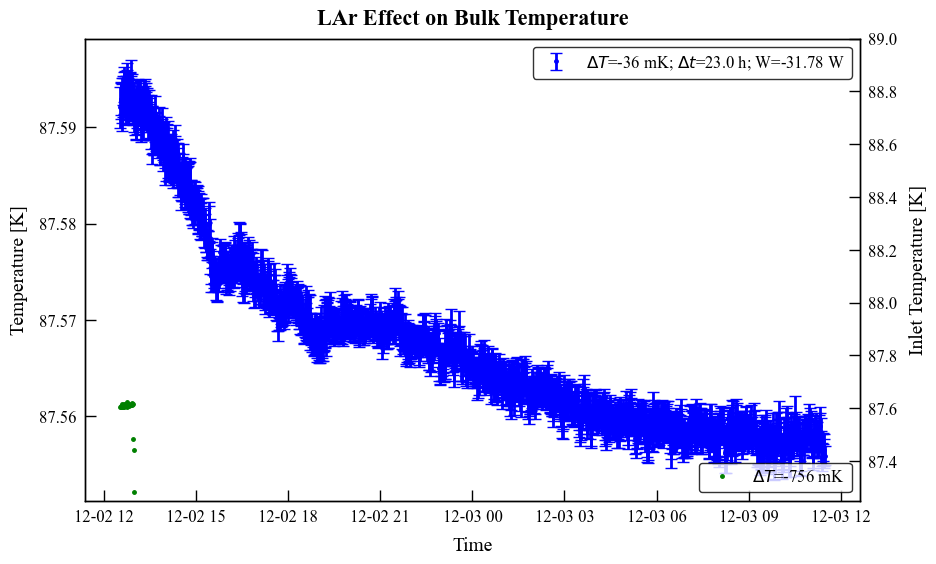

In [23]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
lar_effect = bulk.middle.loc[(bulk.middle.index>t1_ini)&(bulk.middle.index<t1_end)]
inlet_effect = inlet.data.loc[(inlet.data.index>t1_ini)&(inlet.data.index<t1_end)]
deltaT_lar = lar_effect['mean'].iloc[-1] - lar_effect['mean'].iloc[0]
deltat_lar = lar_effect.index[-1] - lar_effect.index[0]
deltaT_inlet = inlet_effect.iloc[-1] - inlet_effect.iloc[0]
deltat_inlet = inlet_effect.index[-1] - inlet_effect.index[0]
print("Delta T LAr:", deltaT_lar)
print("Delta t LAr:", deltat_lar)
print("Delta T LAr / Delta t LAr:", deltaT_lar / deltat_lar.total_seconds())

# Constants
mass_lar = 1.4e5  # kg, example mass of liquid argon (adjust as needed)
c_lar = 0.52e3    # J/(kg*K), specific heat capacity of liquid argon

# Time in seconds (27.3 hours)
dt_seconds = deltat_lar.total_seconds()  # Convert timedelta to seconds

# Use deltaT (already defined) as the temperature rise in K
Q = mass_lar * c_lar * deltaT_lar  # Heat produced in Joules
# Calculate average power in Watts (Joules per second)
power_W = Q / dt_seconds
print(f"Average Power: {power_W:.2f} W")
print(f"Heat produced (Q): {Q:.2e} J over {dt_seconds/3600:.1f} h")
axes.errorbar(lar_effect.index, lar_effect['mean'], yerr=lar_effect['std'], fmt='.', label=fr"$\Delta T$={1e3*deltaT_lar:.0f} mK; $\Delta t$={deltat_lar.total_seconds()/3600:.1f} h; W={power_W:.2f} W", color="blue")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("LAr Effect on Bulk Temperature")
# axes.set_ylim(87.25, 87.8)
axes.legend()
axes2 = axes.twinx()
axes2.plot(inlet_effect.index, inlet_effect.values, ".", label=fr"$\Delta T$={1e3*deltaT_inlet:.0f} mK", color="green")
axes2.set_ylabel("Inlet Temperature [K]")
axes2.legend(loc="lower right")
axes2.set_ylim(87.25, 89)

Delta T LAr: 0.05659919871951047
Delta t LAr: 1 days 09:28:00
Delta T LAr / Delta t LAr: 4.6978086586579073e-07
Average Power: 34.20 W
Heat produced (Q): 4.12e+06 J over 33.5 h


(87.25, 89.0)

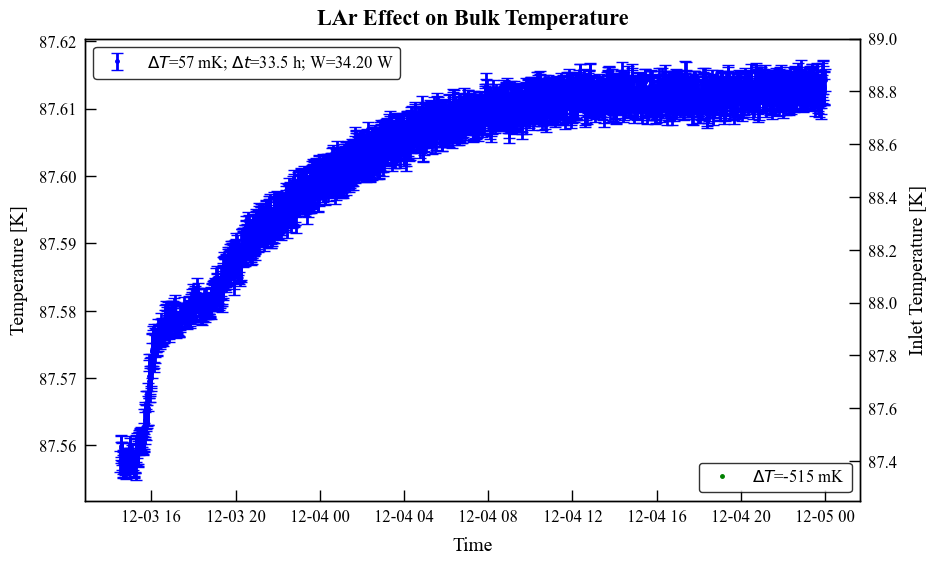

In [24]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
lar_effect = bulk.middle.loc[(bulk.middle.index>t2_ini)&(bulk.middle.index<t2_end)]
inlet_effect = inlet.data.loc[(inlet.data.index>t2_ini)&(inlet.data.index<t2_end)]
deltaT_lar = lar_effect['mean'].iloc[-1] - lar_effect['mean'].iloc[0]
deltat_lar = lar_effect.index[-1] - lar_effect.index[0]
deltaT_inlet = inlet_effect.iloc[-1] - inlet_effect.iloc[0]
deltat_inlet = inlet_effect.index[-1] - inlet_effect.index[0]
print("Delta T LAr:", deltaT_lar)
print("Delta t LAr:", deltat_lar)
print("Delta T LAr / Delta t LAr:", deltaT_lar / deltat_lar.total_seconds())

# Constants
mass_lar = 1.4e5  # kg, example mass of liquid argon (adjust as needed)
c_lar = 0.52e3    # J/(kg*K), specific heat capacity of liquid argon

# Time in seconds (27.3 hours)
dt_seconds = deltat_lar.total_seconds()  # Convert timedelta to seconds

# Use deltaT (already defined) as the temperature rise in K
Q = mass_lar * c_lar * deltaT_lar  # Heat produced in Joules
# Calculate average power in Watts (Joules per second)
power_W = Q / dt_seconds
print(f"Average Power: {power_W:.2f} W")
print(f"Heat produced (Q): {Q:.2e} J over {dt_seconds/3600:.1f} h")
axes.errorbar(lar_effect.index, lar_effect['mean'], yerr=lar_effect['std'], fmt='.', label=fr"$\Delta T$={1e3*deltaT_lar:.0f} mK; $\Delta t$={deltat_lar.total_seconds()/3600:.1f} h; W={power_W:.2f} W", color="blue")
axes.set_xlabel("Time")
axes.set_ylabel("Temperature [K]")
axes.set_title("LAr Effect on Bulk Temperature")
# axes.set_ylim(87.25, 87.8)
axes.legend()
axes2 = axes.twinx()
axes2.plot(inlet_effect.index, inlet_effect.values, ".", label=fr"$\Delta T$={1e3*deltaT_inlet:.0f} mK", color="green")
axes2.set_ylabel("Inlet Temperature [K]")
axes2.legend(loc="lower right")
axes2.set_ylim(87.25, 89)

577.50975 808513.65


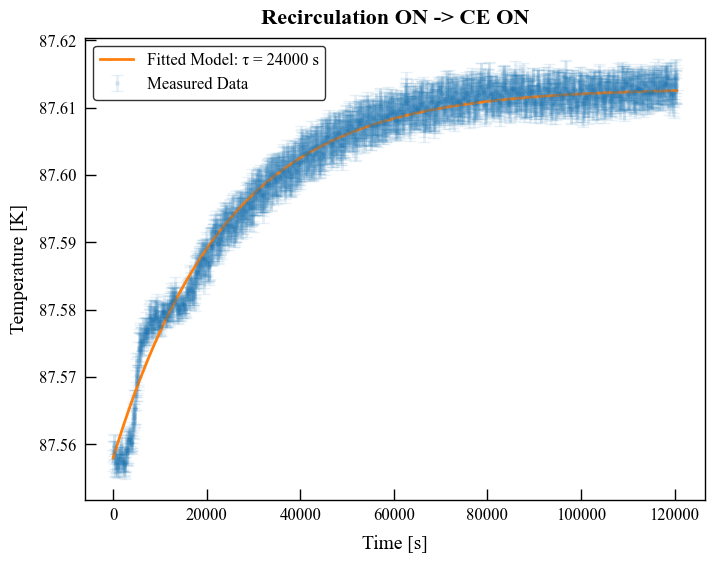

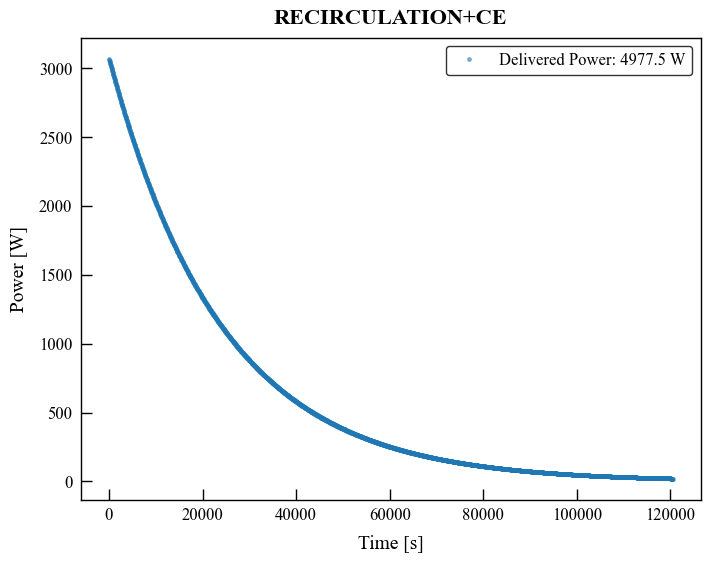

In [ ]:
from scipy.optimize import curve_fit
t2_end = datetime.datetime(2024, 12, 5, 0, 0)
lar_effect = bulk.middle.loc[(bulk.middle.index>t2_ini)&(bulk.middle.index<t2_end)]
inlet_effect = inlet.data.loc[(inlet.data.index>t2_ini)&(inlet.data.index<t2_end)]
T0 = lar_effect.loc[(lar_effect.index > t2_ini) & (lar_effect.index < t2_ini + datetime.timedelta(minutes=30))]['mean'].mean()
# T0 = inlet_effect.loc[(inlet_effect.index > t2_ini) & (inlet_effect.index < t2_ini + datetime.timedelta(minutes=30))].mean()
T_inf = lar_effect.loc[(lar_effect.index > t2_end - datetime.timedelta(minutes=30)) & (lar_effect.index < t2_end)]['mean'].mean()
time = (lar_effect.index - lar_effect.index[0]).total_seconds()
tau_guess = 1e4# Initial guess for tau in seconds

def heat_model(t, tau):
    """Exponential decay model for heat transfer."""
    return T_inf - (T_inf - T0) * (np.exp(-t / tau))

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.errorbar(time, lar_effect['mean'], yerr=lar_effect['std'], fmt='.', label="Measured Data", color="tab:blue", alpha=0.1)
popt, pcov = curve_fit(heat_model, time, lar_effect['mean'], p0=[tau_guess])
tau_fit = popt[0]
axes.plot(time, heat_model(time, tau_fit), label=f"Fitted Model: τ = {round(tau_fit, -2):.0f} s", color='tab:orange')
axes.set_xlabel("Time [s]")
axes.set_ylabel("Temperature [K]")
axes.set_title("Recirculation ON -> CE ON")
axes.legend()

cryostat_height = 7.90
cryostat_width = 8.55
cryostat_length = 8.55
volume = cryostat_height * cryostat_width * cryostat_length  # m^3
density_lar = 1.4e3  # kg/m^3, density of liquid argon

m = density_lar*volume # kg, mass of liquid argon
print(volume, m)
c_steel = 8.327e8
c = 1660  # J/(kg*K), specific heat capacity of liquid argon
def heat_model_derivative(t, tau):
    """First derivative of the heat_model with respect to t."""
    return m*c*(((T_inf - T0) / tau) * np.exp(-t / tau))

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.errorbar(time, heat_model_derivative(time, tau_fit), fmt='.', label=fr"Delivered Power: {(m*c + c_steel)*(T_inf - T0)/tau_fit:.1f} W", color="tab:blue", alpha=0.5)
axes.set_xlabel("Time [s]")
axes.set_ylabel("Power [W]")
axes.set_title("RECIRCULATION+CE")
axes.legend()


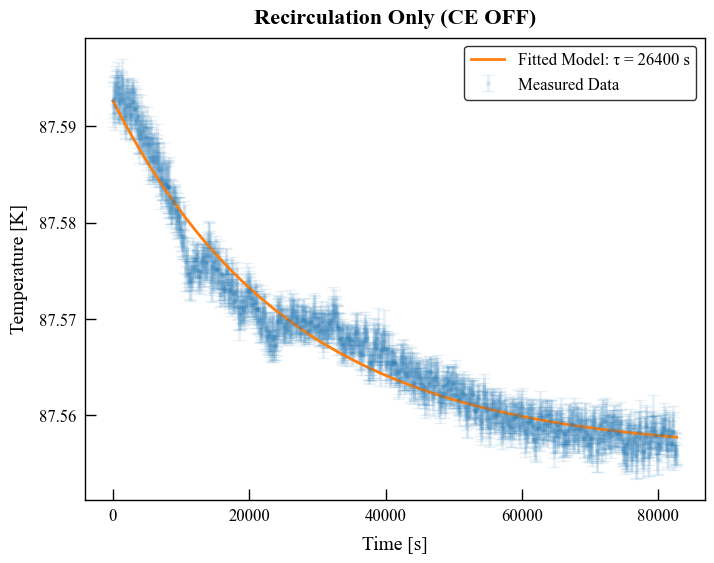

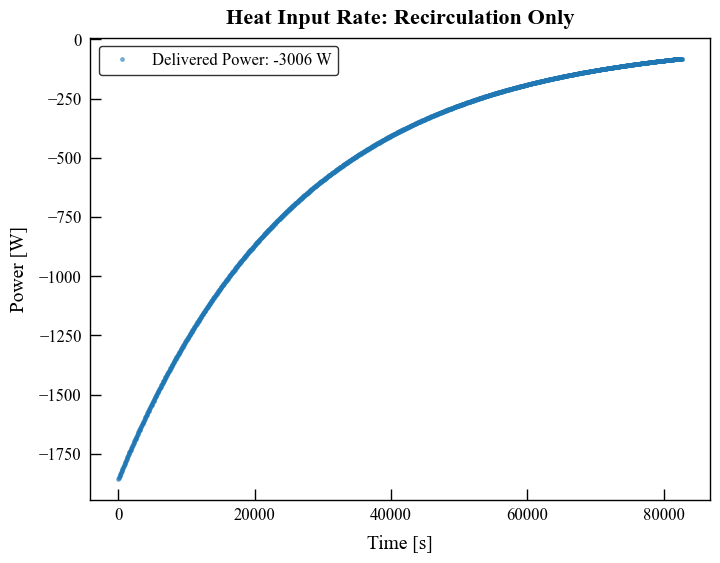

In [93]:
from scipy.optimize import curve_fit
lar_effect = bulk.middle.loc[(bulk.middle.index>t1_ini)&(bulk.middle.index<t1_end)]
inlet_effect = inlet.data.loc[(inlet.data.index>t1_ini)&(inlet.data.index<t1_end)]
T0 = lar_effect.loc[(lar_effect.index > t1_ini) & (lar_effect.index < t1_ini + datetime.timedelta(minutes=5))]['mean'].mean()
# T0 = inlet_effect.loc[(inlet_effect.index > t2_ini) & (inlet_effect.index < t2_ini + datetime.timedelta(minutes=30))].mean()
T_inf = lar_effect.loc[(lar_effect.index > t1_end - datetime.timedelta(minutes=5)) & (lar_effect.index < t1_end)]['mean'].mean()
time = (lar_effect.index - lar_effect.index[0]).total_seconds()
tau_guess = 1e4# Initial guess for tau in seconds

def heat_model(t, tau):
    """Exponential decay model for heat transfer."""
    return T_inf - (T_inf - T0) * (np.exp(-t / tau))

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.errorbar(time, lar_effect['mean'], yerr=lar_effect['std'], fmt='.', label="Measured Data", color="tab:blue", alpha=0.1)
popt, pcov = curve_fit(heat_model, time, lar_effect['mean'], p0=[tau_guess])
tau_fit = popt[0]
axes.plot(time, heat_model(time, tau_fit), label=f"Fitted Model: τ = {round(tau_fit, -2):.0f} s", color='tab:orange')
axes.set_xlabel("Time [s]")
axes.set_ylabel("Temperature [K]")
axes.set_title("Recirculation Only (CE OFF)")
axes.legend()

def heat_model_derivative(t, tau):
    """First derivative of the heat_model with respect to t."""
    return m*c*(((T_inf - T0) / tau) * np.exp(-t / tau))

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.errorbar(time, heat_model_derivative(time, tau_fit), fmt='.', label=fr"Delivered Power: {(m*c + c_steel)*(T_inf - T0)/tau_fit:.0f} W", color="tab:blue", alpha=0.5)
axes.set_xlabel("Time [s]")
axes.set_ylabel("Power [W]")
axes.set_title("Heat Input Rate: Recirculation Only")
axes.legend()


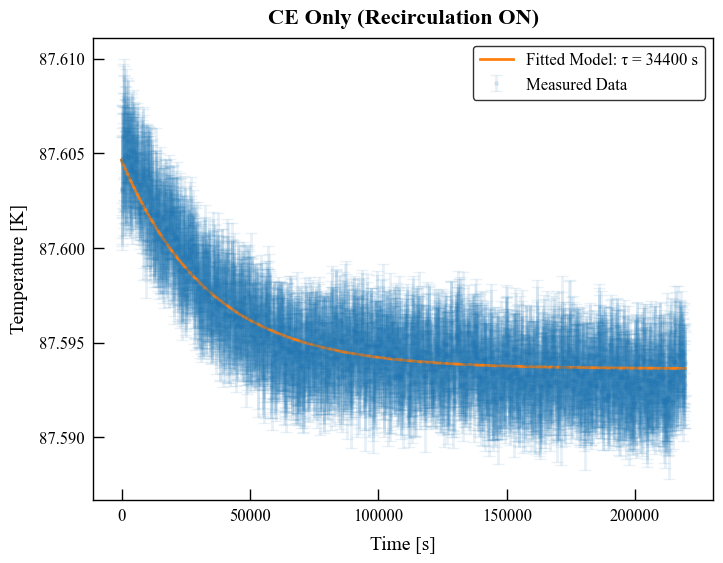

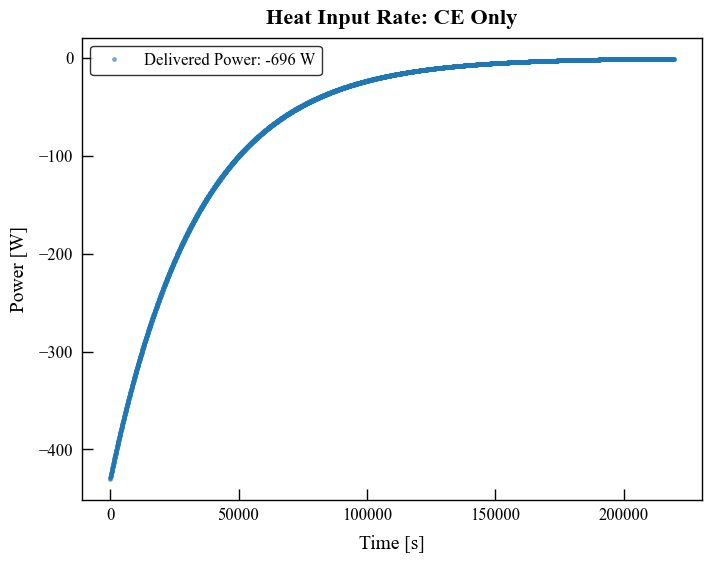

In [94]:
from scipy.optimize import curve_fit
lar_effect = bulk.middle.loc[(bulk.middle.index>t0_ini)&(bulk.middle.index<t0_end)]
inlet_effect = inlet.data.loc[(inlet.data.index>t0_ini)&(inlet.data.index<t0_end)]
T0 = lar_effect.loc[(lar_effect.index > t0_ini) & (lar_effect.index < t0_ini + datetime.timedelta(minutes=30))]['mean'].mean()
# T0 = inlet_effect.loc[(inlet_effect.index > t2_ini) & (inlet_effect.index < t2_ini + datetime.timedelta(minutes=30))].mean()
T_inf = lar_effect.loc[(lar_effect.index > t0_end - datetime.timedelta(minutes=30)) & (lar_effect.index < t0_end)]['mean'].mean()
time = (lar_effect.index - lar_effect.index[0]).total_seconds()
tau_guess = 1e4# Initial guess for tau in seconds

def heat_model(t, tau):
    """Exponential decay model for heat transfer."""
    return T_inf - (T_inf - T0) * (np.exp(-t / tau))

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.errorbar(time, lar_effect['mean'], yerr=lar_effect['std'], fmt='.', label="Measured Data", color="tab:blue", alpha=0.1)
popt, pcov = curve_fit(heat_model, time, lar_effect['mean'], p0=[tau_guess])
tau_fit = popt[0]
axes.plot(time, heat_model(time, tau_fit), label=f"Fitted Model: τ = {round(tau_fit, -2):.0f} s", color='tab:orange')
axes.set_xlabel("Time [s]")
axes.set_ylabel("Temperature [K]")
axes.set_title("CE Only (Recirculation ON)")
axes.legend()

def heat_model_derivative(t, tau):
    """First derivative of the heat_model with respect to t."""
    return m*c*(((T_inf - T0) / tau) * np.exp(-t / tau))

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.errorbar(time, heat_model_derivative(time, tau_fit), fmt='.', label=fr"Delivered Power: {(m*c+c_steel)*(T_inf - T0)/tau_fit:.0f} W", color="tab:blue", alpha=0.5)
axes.set_xlabel("Time [s]")
axes.set_ylabel("Power [W]")
axes.set_title("Heat Input Rate: CE Only")
axes.legend()


In [70]:
pressure1 = sensorClasses.Sensor(dataset=dataset, id=1011)
pressure2 = sensorClasses.Sensor(dataset=dataset, id=1012)
ambient_pressure = sensorClasses.Sensor(dataset=dataset, id=1038)
pump_pressure = sensorClasses.Sensor(dataset=dataset, id=1048)
lar_pressure1 = sensorClasses.Sensor(dataset=dataset, id=1050)
lar_pressure2 = sensorClasses.Sensor(dataset=dataset, id=1051)
lar_flow = sensorClasses.Sensor(dataset=dataset, id=1049)
level1 = sensorClasses.Sensor(dataset=dataset, id=1040)
level2 = sensorClasses.Sensor(dataset=dataset, id=1041)
cryostat_height = 8550.4

-504.7266300374084


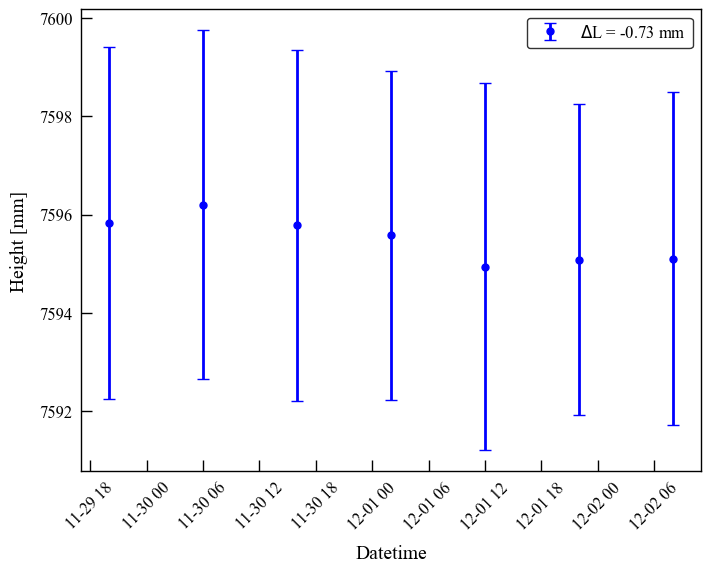

In [77]:
resampling_period = "600min"
level_effect = level2.data.loc[(level2.data.index>t0_ini)&(level2.data.index<t0_end)]
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
delta_l = (level_effect.resample(resampling_period).mean().iloc[-1] - level_effect.resample(resampling_period).mean().iloc[0]) * cryostat_height / 100
delta_m = cryostat_length*cryostat_width*(delta_l/1000)*density_lar
lar_mol = delta_m*1e3 / 39.95
heat_vapor = lar_mol*6447  # kJ/mol, heat of vaporization for argon
print(heat_vapor/tau_fit)
axes.errorbar(level_effect.resample(resampling_period).mean().index, cryostat_height * level_effect.resample(resampling_period).mean().values / 100, yerr=cryostat_height*level_effect.resample(resampling_period).std().values / 100, fmt="o", label=fr"$\Delta$L = {delta_l:.2f} mm", color="blue")
# axes.set_xlim(pd.Timestamp(t0_ini), pd.Timestamp(t0_end))
# axes.set_ylim(7580, 7610)
axes.set_xlabel("Datetime")
axes.set_ylabel("Height [mm]")
axes.tick_params(axis='x', rotation=45)
axes.legend()

-26785.743980296567


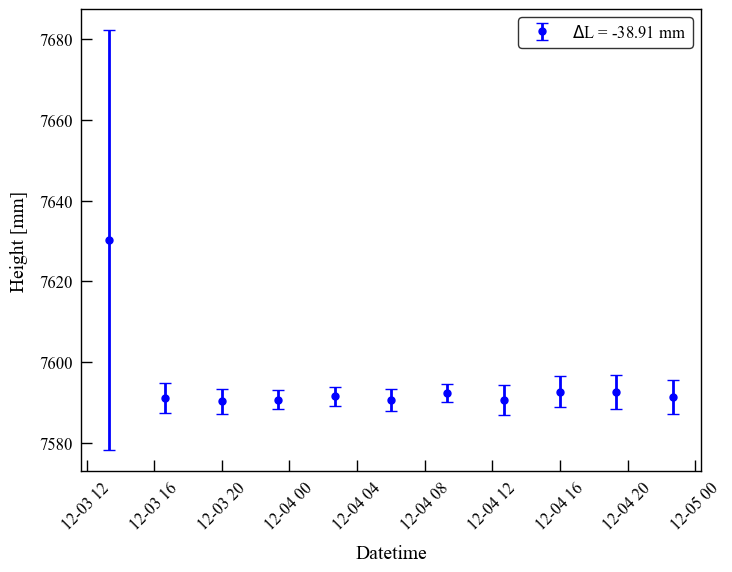

In [87]:
resampling_period = "200min"
level_effect = level2.data.loc[(level2.data.index>t2_ini)&(level2.data.index<t2_end)]
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
delta_l = (level_effect.resample(resampling_period).mean().iloc[-1] - level_effect.resample(resampling_period).mean().iloc[0]) * cryostat_height / 100
delta_m = cryostat_length*cryostat_width*(delta_l/1000)*density_lar
lar_mol = delta_m*1e3 / 39.95
heat_vapor = lar_mol*6447  # kJ/mol, heat of vaporization for argon
print(heat_vapor/tau_fit)
axes.errorbar(level_effect.resample(resampling_period).mean().index, cryostat_height * level_effect.resample(resampling_period).mean().values / 100, yerr=cryostat_height*level_effect.resample(resampling_period).std().values / 100, fmt="o", label=fr"$\Delta$L = {delta_l:.2f} mm", color="blue")
# axes.set_xlim(pd.Timestamp(t0_ini), pd.Timestamp(t0_end))
# axes.set_ylim(7580, 7610)
axes.set_xlabel("Datetime")
axes.set_ylabel("Height [mm]")
axes.tick_params(axis='x', rotation=45)
axes.legend()